In [61]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
import numpy as np
import matplotlib.pyplot as plt

from snudd import config
from snudd.geometry import SolarAngles
from snudd.nsi import earth_matter, nsi_probabilities
from snudd.models import GeneralNSI, SM

from snudd.targets import nucleus_xe, electron_xe

In [63]:
nsi_model = GeneralNSI(np.array([[0, 0, 0],
                                [0, 0, 0],
                                [0, 0, 0]]),
                                0, 0)

nucleus_xe.update_model(nsi_model)


In [64]:
E_nus = np.geomspace(4e-3,1e1, 500) / 1e3

## Testing earth evolution

In [65]:
t0 = 91
T  = 182*2

GranSasso = SolarAngles(latitude=42.47, t0=t0, T=T)
cnadirs, weights = GranSasso.cnadir_hist(bins=50)

print(len(cnadirs), len(weights))

50 50


In [66]:
DensityCalc = nsi_probabilities.DensityMatrixEarthCalculator(nsi_model)
# DensityCalc = nsi_probabilities.DensityMatrixEarthCalculator(nsi_model, cnadirs=[np.cos(np.pi/4)])

interpolated_rhos = DensityCalc.interpolate_earth_density_elements(cnadirs=cnadirs)


# # 
# import cProfile


# cProfile.run("DensityCalc.interpolate_earth_density_elements()")

In [67]:
print(np.arccos(cnadirs)/np.pi)

E_nus   = np.geomspace(3.4640e-3, 1.8784e1, 200) / 1e3
rho_els = interpolated_rhos['8B'][0](E_nus)

rhos = DensityCalc.matrix_from_elements(rho_els)
print(rhos.shape)

[0.11360934 0.12938041 0.14515148 0.16092255 0.17669361 0.19246468
 0.20823575 0.22400682 0.23977789 0.25554895 0.27132002 0.28709109
 0.30286216 0.31863322 0.33440429 0.35017536 0.36594643 0.3817175
 0.39748856 0.41325963 0.4290307  0.44480177 0.46057283 0.4763439
 0.49211497 0.50788604 0.52365711 0.53942817 0.55519924 0.57097031
 0.58674138 0.60251244 0.61828351 0.63405458 0.64982565 0.66559672
 0.68136778 0.69713885 0.71290992 0.72868099 0.74445205 0.76022312
 0.77599419 0.79176526 0.80753633 0.82330739 0.83907846 0.85484953
 0.8706206  0.88639166]
(200, 3, 3)


In [68]:
nucleus_xe.prepare_density()


E_nus = np.geomspace(4e-3,1e1, 500) / 1e3

nucleus_xe._spec.nu_density_elements["8B"][0](E_nus)

array([[ 5.49311716e-01,  5.49309938e-01,  5.49308131e-01, ...,
         3.27642266e-01,  3.26667037e-01,  3.25715442e-01],
       [-1.39830580e-18,  9.27306917e-19,  2.39361778e-18, ...,
        -3.00919113e-18, -9.96983981e-18, -1.07545040e-17],
       [ 5.14257790e-02,  5.14233011e-02,  5.14207840e-02, ...,
        -2.57408810e-01, -2.58767520e-01, -2.60093301e-01],
       ...,
       [ 1.36792084e-02,  1.36788644e-02,  1.36785150e-02, ...,
        -2.91915628e-02, -2.93801716e-02, -2.95642095e-02],
       [ 2.35854835e-01,  2.35855120e-01,  2.35855409e-01, ...,
         2.71331685e-01,  2.71487765e-01,  2.71640061e-01],
       [ 2.64811444e-18,  6.97360549e-18, -1.15501144e-18, ...,
         1.84537705e-19, -1.97500643e-19,  1.64876760e-19]],
      shape=(12, 500))

/Users/foldenauer/local/opt/SNuDD/snudd/spectrum.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  """Target (nucleus or electron) spectrum."""


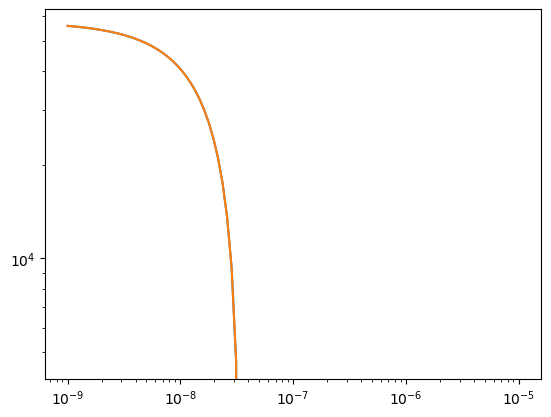

In [69]:
ERs = np.geomspace(1e-3, 1e1, 100) / 1e6

nucleus_xe.prepare_density() 
plt.loglog(ERs, nucleus_xe.spectrum(E_R=ERs, nu='pep'))

nucleus_xe.prepare_density(cnadirs=[1], cnadir_weights=[1])
plt.loglog(ERs, nucleus_xe.spectrum(E_R=ERs, nu='pep'))

/Users/foldenauer/local/opt/SNuDD/snudd/spectrum.py:36: ComplexWarning: Casting complex values to real discards the imaginary part
  


(1.0, 100000000.0)

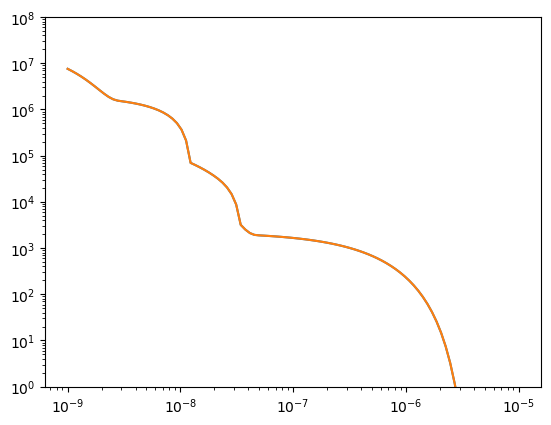

In [70]:
ERs = np.geomspace(1e-3, 1e1, 100) / 1e6


nucleus_xe.prepare_density() 
spec_vac = nucleus_xe.spectrum(E_R=ERs)
plt.loglog(ERs, spec_vac)

nucleus_xe.prepare_density(cnadirs=[1])
# nucleus_xe.prepare_density(cnadirs = [1], cnadir_weights= [1])
spec_mat = nucleus_xe.spectrum(E_R=ERs)
plt.loglog(ERs, spec_mat)

plt.ylim(1e0,1e8)

(1e-05, 100.0)

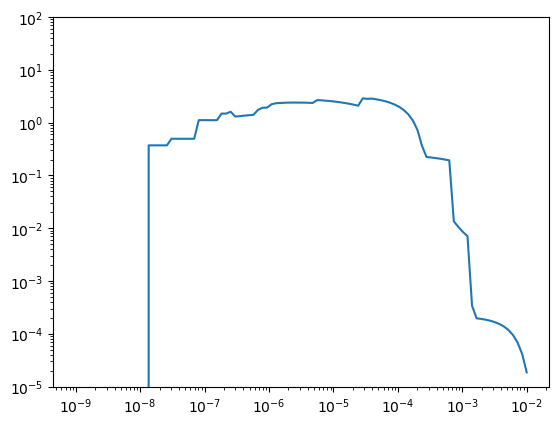

In [71]:
ERs = np.geomspace(1e-3, 1e4, 100) / 1e6


electron_xe.prepare_density(cnadirs=[-1]) 
spec_vac = electron_xe.spectrum(E_R=ERs)

electron_xe.prepare_density(cnadirs=[1])
# nucleus_xe.prepare_density(cnadirs = [1], cnadir_weights= [1])
spec_mat = electron_xe.spectrum(E_R=ERs)
plt.loglog(ERs, spec_mat)

plt.ylim(1e-5,1e2)

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\D'
/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_43635/3889263003.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Recoil Energy, $E_R~\mathrm{[keV]}$")
/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_43635/3889263003.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Day-Night Asymmetry, $\Delta_{\mathrm{DN}}~\mathrm{[\%]}$")
/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_43635/3889263003.py:1: RuntimeWarning: invalid value encountered in divide
  dn_asym = (spec_mat - spec_vac) / (spec_mat + spec_vac) * 2


Text(0, 0.5, 'Day-Night Asymmetry, $\\Delta_{\\mathrm{DN}}~\\mathrm{[\\%]}$')

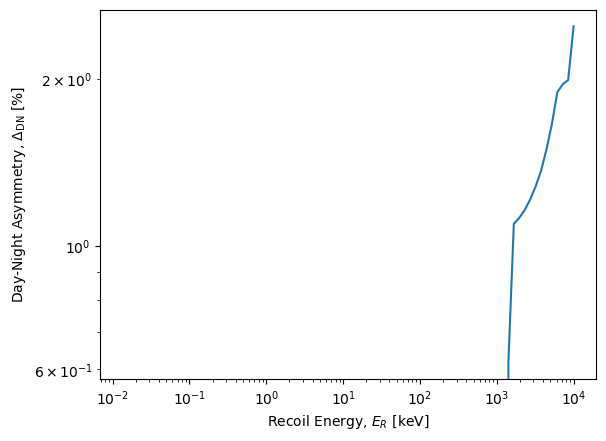

In [72]:
dn_asym = (spec_mat - spec_vac) / (spec_mat + spec_vac) * 2
plt.figure()
plt.loglog(ERs * 1e6, dn_asym * 100)

plt.xlabel("Recoil Energy, $E_R~\mathrm{[keV]}$")
plt.ylabel("Day-Night Asymmetry, $\Delta_{\mathrm{DN}}~\mathrm{[\%]}$")

In [73]:

ERs = np.geomspace(1e-2, 1e4, 500) / 1e6

nus = config.NU_SOURCE_KEYS
spectrum_day = {nu: np.zeros_like(ERs) for nu in nus}
spectrum_night = {nu: np.zeros_like(ERs) for nu in nus}

### DAY ###
electron_xe.prepare_density(cnadirs=[-1]) 
for i, nu in enumerate(nus):
    spectrum_day[nu] = electron_xe.spectrum(E_R=ERs, nu=nu)
spectrum_day_tot = electron_xe.spectrum(E_R=ERs) 

### NIGHT ###
electron_xe.prepare_density(cnadirs=[1])
for i, nu in enumerate(nus):
    spectrum_night[nu] = electron_xe.spectrum(E_R=ERs, nu=nu)
spectrum_night_tot = electron_xe.spectrum(E_R=ERs) 

In [74]:
def compute_flux_weights(spectrum_day, spectrum_night):

    spectrum_tot_av = np.zeros(spectrum_day['8B'].shape[0])
    for nu in nus:
        spectrum_tot_av += (spectrum_day[nu] + spectrum_night[nu])/2
        
    weights = {nu: (spectrum_day[nu] + spectrum_night[nu])/2 / spectrum_tot_av for nu in nus}
    return weights, spectrum_tot_av


def compute_dn_asym(spectrum_day, spectrum_night):
    """Compute day-night asymmetry given the day and night spectra IN %."""
    average = (spectrum_night + spectrum_day) / 2
    difference = spectrum_night - spectrum_day
    asym = np.where(difference != 0., difference / average * 100, 0)
    return asym

In [75]:
weights, spectrum_tot_av = compute_flux_weights(spectrum_day, spectrum_night)

/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_43635/4158601131.py:7: RuntimeWarning: invalid value encountered in divide
  weights = {nu: (spectrum_day[nu] + spectrum_night[nu])/2 / spectrum_tot_av for nu in nus}


In [76]:
weights['8B']

array([           nan,            nan,            nan,            nan,
                  nan,            nan,            nan, 6.63462627e-05,
       6.63463420e-05, 6.63464236e-05, 6.63465074e-05, 6.63465936e-05,
       6.63466822e-05, 6.63467733e-05, 6.63468670e-05, 6.63469633e-05,
       6.63470623e-05, 6.63471641e-05, 6.63472687e-05, 6.63473763e-05,
       6.63474869e-05, 6.63476006e-05, 6.63477175e-05, 6.63478376e-05,
       6.63479612e-05, 6.63480882e-05, 6.63482188e-05, 6.63483530e-05,
       6.63484911e-05, 6.63486329e-05, 6.63487788e-05, 6.63489288e-05,
       6.63490830e-05, 6.63492415e-05, 6.63494044e-05, 6.63495720e-05,
       6.63497442e-05, 6.63499213e-05, 6.63501033e-05, 6.63502905e-05,
       6.63504829e-05, 6.63506807e-05, 6.63508841e-05, 6.63510932e-05,
       6.63513081e-05, 6.63515291e-05, 6.63517563e-05, 6.63519899e-05,
       6.63522300e-05, 6.63524769e-05, 6.63527307e-05, 6.63529916e-05,
       6.63532599e-05, 6.63535357e-05, 6.63538192e-05, 6.63541107e-05,
      

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\D'
/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_43635/1117833031.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Recoil Energy, $E_R~\mathrm{[keV]}$")
/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_43635/1117833031.py:15: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Day-Night Asymmetry, $\Delta_{\mathrm{DN}}~\mathrm{[\%]}$")
/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_43635/4158601131.py:15: RuntimeWarning: invalid value encountered in divide
  asym = np.where(difference != 0., difference / average * 100, 0)


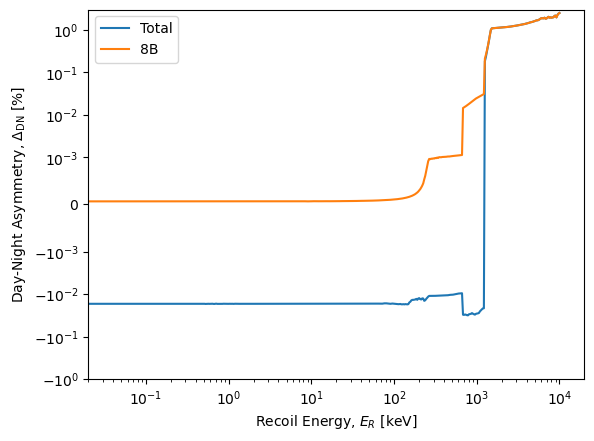

In [77]:
nu = '15O'
nu2 = '8B'
fig, ax = plt.subplots()
plt.loglog(ERs * 1e6, compute_dn_asym(spectrum_day_tot, spectrum_night_tot), label='Total')
# plt.loglog(ERs * 1e6, weights[nu] * compute_dn_asym(spectrum_day[nu], spectrum_night[nu]))
plt.loglog(ERs * 1e6, weights[nu2] * compute_dn_asym(spectrum_day[nu2], spectrum_night[nu2]), label='8B')

# plt.xlim(1e3, 3e3)

ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=1e-3)
plt.xlim(2e-2)
plt.ylim(-1, 3)
plt.xlabel("Recoil Energy, $E_R~\mathrm{[keV]}$")
plt.ylabel("Day-Night Asymmetry, $\Delta_{\mathrm{DN}}~\mathrm{[\%]}$")
plt.legend()

In [78]:
spec_mat - spec_vac

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -6.27645791e-05, -6.27639508e-05, -6.27632113e-05, -6.27623411e-05,
       -6.27613171e-05, -8.36801493e-05, -8.36782583e-05, -8.36760331e-05,
       -8.36702660e-05, -8.36785091e-05, -8.36574791e-05, -1.88245515e-04,
       -1.88236150e-04, -1.88364796e-04, -1.88316021e-04, -1.88319969e-04,
       -2.51126583e-04, -2.50660929e-04, -2.71862953e-04, -2.20554048e-04,
       -2.24898425e-04, -2.29390490e-04, -2.32713976e-04, -2.37097156e-04,
       -2.96719046e-04, -3.23528824e-04, -3.27044225e-04, -3.77225539e-04,
       -3.94682533e-04, -3.99618490e-04, -4.02919332e-04, -4.04885530e-04,
       -4.05887052e-04, -4.04592858e-04, -4.03909426e-04, -4.02171480e-04,
       -3.98595713e-04, -